# Anatomy of a reconstruction — seeds, the longitudinal basin, and convergence

*Why* `fit_track_multistart` works, on one event: the two complementary seeds (charge-grid vs
time-multilateration), the loss basin along the hard **longitudinal** direction, and the
convergence — with the residual decomposed by the `lucid.fitting.analysis` seam. The companion to
`reconstruct_a_track.ipynb` (which just runs the fit).

In [1]:
%matplotlib inline
import sys; sys.path.append('../..')
import jax, jax.numpy as jnp, numpy as np
import matplotlib.pyplot as plt
from lucid.geometry import generate_detector
from lucid.simulation import setup_event_simulator
from lucid.detector_params import load_detector_params
from lucid.sources.event_io import read_photon_data_from_photonsim, pad_photon_data
from lucid.fitting import (ReconModel, fit_track_multistart, track_from_vec9, vec9_from_track,
                           vec9_dir, seed_vertex_time)
from lucid.fitting.analysis import vertex_residual, angular_error_deg
from lucid.optimization.grid_search import hierarchical_position_grid_search, get_detector_bounds
from lucid.optimization.utils.functions import hierarchical_direction_search_cone, energy_scan_optimization

GEOM = '../../config/SK_like_geom_config.json'; PHYS = '../../config/SK_like_physics_config.json'
ROOT = '/sdf/group/neutrino/omara/LUCiD_recon/data/water/muon/muon_gun_1050_MeV_100_events_fixed_energy.root'
K, NBUF, NPH = 8, 400_000, 250_000; GRID = dict(n_cap=80, n_angular=120, n_height=80); EV = 3
det = generate_detector(GEOM); ND = len(det.all_points); POS = np.asarray(det.all_points)
bounds = get_detector_bounds(det)
dp = load_detector_params(PHYS, num_sensors=ND)._replace(
        response=load_detector_params(PHYS, num_sensors=ND).response._replace(tts=jnp.asarray(2.5)))
data_sim = setup_event_simulator(GEOM, NBUF, temperature=None, K=K, is_data=True, hit_mode='realistic',
                                 physics_config=PHYS, default_detector_params=dp, particle='muon',
                                 wavelength_mode=True, apply_smearing=False, **GRID)
pred = setup_event_simulator(GEOM, NPH, temperature=0.1, K=K, hit_mode='per_photon', physics_config=PHYS,
                             default_detector_params=True, particle='muon', wavelength_mode=True,
                             pos_grad_threshold=K, n_grad_iters=K, **GRID)
model = ReconModel(pred, ND, sigma=2.5, delta=1.0)

### Event + exact gun truth (origin, +z transformed) + the data

In [2]:
def rotax(u, deg):
    a=np.radians(deg); ca,sa=np.cos(a),np.sin(a); u=u/np.linalg.norm(u)
    ux=np.array([[0,-u[2],u[1]],[u[2],0,-u[0]],[-u[1],u[0],0]]); return np.eye(3)*ca+sa*ux+(1-ca)*np.outer(u,u)
R=rotax(np.array([0.2,0.9,0.]), 60.); sh=np.array([-6.,2.,5.])*100.
raw=read_photon_data_from_photonsim(ROOT,EV); O=np.asarray(raw['photon_origins']).astype(float); c=O.mean(0)
raw=dict(raw); raw['photon_origins']=(O-c)@R.T+c+sh; raw['photon_directions']=np.asarray(raw['photon_directions']).astype(float)@R.T
vtx_true=((np.zeros(3)-c)@R.T+c+sh)/100.; dir_true=np.array([0.,0.,1.])@R.T
pd,n=pad_photon_data(raw,NBUF)
dummy=track_from_vec9(jnp.array([1050.,0,0,0,0.,1.,0.,1.,0.]))
cc,tt=jax.lax.stop_gradient(data_sim(dummy,jax.random.PRNGKey(7000+EV),pd))
oc=np.asarray(cc); ot=np.where(oc>0,np.asarray(tt),0.); ocf,otf=jnp.asarray(oc),jnp.asarray(ot)
print(f'event {EV}: {int((oc>0).sum())} PMTs lit | truth vtx {np.round(vtx_true,2)} m')

event 3: 2325 PMTs lit | truth vtx [-7.75  2.39  6.06] m


### The two seeds — complementary

The **charge-grid** seed (Cherenkov ring) fixes direction but is degenerate *along* the track; the
**time-multilateration** seed (`seed_vertex_time`) nails the transverse vertex but is biased forward
along the track. `fit_track_multistart` runs from both and keeps the lower-loss basin.

In [3]:
POSf=jnp.asarray(POS)
e0=energy_scan_optimization(pred, jnp.zeros(3), jnp.arccos(1/jnp.sqrt(3)), jnp.pi/4, 0., POSf, otf, ocf,
                            (ocf,otf), 1000., 700., 12, 0)['best_energy']
def make_seed(vtx,t0g):
    c2=hierarchical_direction_search_cone(pred, jnp.asarray(vtx), t0g, POSf, otf, ocf, (ocf,otf), e0, 3,8,90.,0.5,0)
    dg=np.array([np.sin(c2['best_theta'])*np.cos(c2['best_phi']), np.sin(c2['best_theta'])*np.sin(c2['best_phi']), np.cos(c2['best_theta'])])
    return vec9_from_track(e0, np.asarray(vtx), dg, t0=t0g)
p1=hierarchical_position_grid_search(POSf,otf,ocf,jnp.zeros(3),0.,0.,bounds,n_div=5,t0_n_div=5,levels=6,verbosity=0)
seedA=make_seed(np.asarray(p1['best_position']), float(p1['best_t0']))   # charge grid
seedB=make_seed(*seed_vertex_time(POS,oc,ot))                            # time multilateration
for nm,s in [('charge-grid (A)',seedA),('time-multilat (B)',seedB)]:
    lon,tra=vertex_residual(s[1:4], vtx_true, dir_true)
    print(f'  {nm:18s} vtx err {np.linalg.norm(s[1:4]-vtx_true)*100:5.0f} cm  (longitudinal {lon*100:+5.0f}, transverse {tra*100:4.0f})')

  charge-grid (A)    vtx err    94 cm  (longitudinal   +44, transverse   83)
  time-multilat (B)  vtx err   281 cm  (longitudinal  +280, transverse   29)


### The longitudinal loss basin — the hard direction (charge is degenerate along the track)

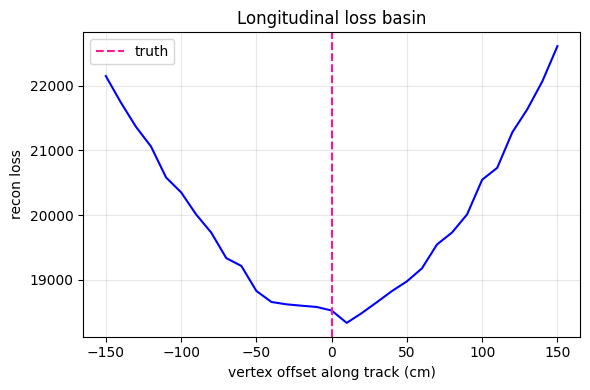

In [4]:
key=jax.random.PRNGKey(1); off=np.linspace(-1.5,1.5,31); ls=[]
for s in off:
    t9=vec9_from_track(1050., vtx_true+s*dir_true, dir_true, t0=0.)
    ls.append(float(model.loss(jnp.asarray(t9), ocf, otf, key)))
fig,ax=plt.subplots(figsize=(6,4)); ax.plot(off*100, ls, 'b-'); ax.axvline(0, color='deeppink', ls='--', label='truth')
ax.set_xlabel('vertex offset along track (cm)'); ax.set_ylabel('recon loss'); ax.set_title('Longitudinal loss basin'); ax.legend(); ax.grid(alpha=.3)
fig.tight_layout(); plt.show()

### The fit — convergence of the winning basin + final residual

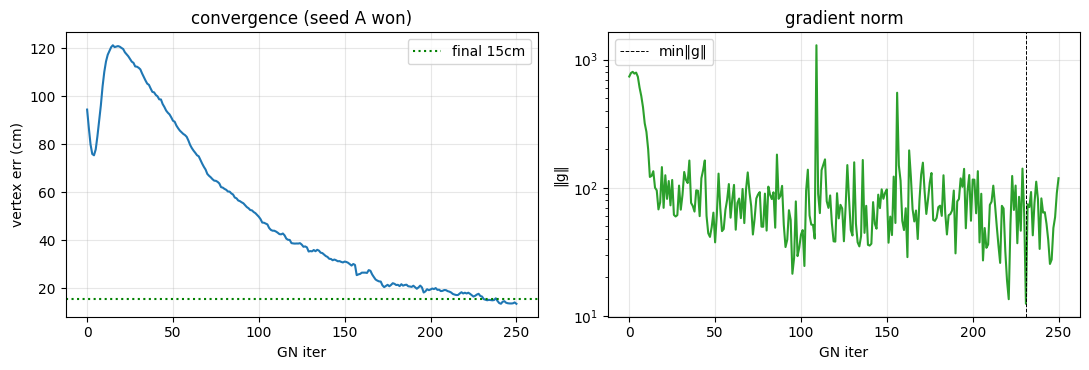

FINAL: vtx 15.4 cm (lon -5, tra 15) | dir 0.75 deg | E +10 MeV


In [5]:
res,MS=fit_track_multistart(model, oc, ot, [seedA,seedB], nkeys=4, niters=250)
H=MS['per_seed'][MS['which']][1]; tr=H['traj']; it=np.arange(len(tr))
verr=np.linalg.norm(tr[:,1:4]-vtx_true,axis=1)*100
lon,tra=vertex_residual(res[1:4], vtx_true, dir_true); ang=angular_error_deg(vec9_dir(res), dir_true)
fig,ax=plt.subplots(1,2,figsize=(11,3.8))
ax[0].plot(it,verr); ax[0].axhline(verr[H['best_iter']],color='g',ls=':',label=f'final {verr[H["best_iter"]]:.0f}cm'); ax[0].set(xlabel='GN iter',ylabel='vertex err (cm)',title=f'convergence (seed {"AB"[MS["which"]]} won)'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].semilogy(it,H['gnorm'],color='C2'); ax[1].axvline(H['best_iter'],ls='--',c='k',lw=.7,label='min‖g‖'); ax[1].set(xlabel='GN iter',ylabel='‖g‖',title='gradient norm'); ax[1].legend(); ax[1].grid(alpha=.3)
fig.tight_layout(); plt.show()
print(f'FINAL: vtx {np.linalg.norm(res[1:4]-vtx_true)*100:.1f} cm (lon {lon*100:+.0f}, tra {tra*100:.0f}) | dir {ang:.2f} deg | E {res[0]-1050.:+.0f} MeV')

Read top to bottom: the time seed lands transverse-perfect but forward-biased; the charge seed
the reverse; the longitudinal basin is shallow (why that direction is the resolution floor); the fit
converges to the min-‖g‖ iterate. Decompose any campaign's errors the same way with
`lucid.fitting.analysis` (`vertex_residual`, `resolution_stats`, `bootstrap_ci`).